In [1]:
import numpy as np
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
from IPython.display import display, HTML
from statsmodels import robust
import pickle
from scipy.ndimage import filters
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import auc
display(HTML("<style>.container { width:65% !important; }</style>"))

In [34]:
boris_dir = 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\'
boris_files = np.sort([boris_dir + x for x in os.listdir(boris_dir) if '.csv' in x and '._' not in x])
print('Sample boris files:')
print(boris_files)

Sample boris files:
['C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162B_d9_OBSmCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162B_d9_OBSmCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162B_d9_OBSmCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162L2_d9_toyCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162L2_d9_toyCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162L2_d9_toyCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162R_d9_toyCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162R_d9_toyCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162R_d9_toyCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1185_d9_OBSmCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1185_d9_OBSmCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1185_d9_OBSmCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\29L_d9_OBSmCD1_t1.csv'
 'C:\\Users\\FalknerLab\\D

Wrangling:

In [35]:
# Functions to parse BORIS CSV exports and extract frames for specific behaviors

RESIDENT_UNILATERAL = ['resident_unilateral_attack']
INTRUDER_UNILATERAL = ['intruder_unilateral_attack']
RESIDENT_RESISTANCE = ['resident_attack_with_resistance', 'fight_from_resident_with_resistance']
INTRUDER_RESISTANCE = ['intruder_attack_with_resistance', 'fight_from_intruder_with_resistance']
RESIDENT_FLEE       = ['resident_flee']
IGNORE_BEHAVIORS    = ['fight', 'attack/fight']

REQUIRED_BEHAVIORS  = (RESIDENT_UNILATERAL + INTRUDER_UNILATERAL +
                       RESIDENT_RESISTANCE  + INTRUDER_RESISTANCE  +  RESIDENT_FLEE)

def format_boris_new(boris_path, boris_fps=40):
    """
    Parse BORIS CSV export. Handles three formats:

    Format A: 16-row metadata header, columns Time/Behavior/Status,
              frame = Time * FPS
    Format B: flat CSV with full column set including 'Image index',
              frame taken directly from 'Image index'
    Empty:    16-row header but no data rows — returns None
    """
    try:
        # ── Format A: skiprows=16, minimal columns ────────────────────────
        df = pd.read_csv(boris_path, skiprows=16)
        assert 'Time' in df.columns and 'Behavior' in df.columns, \
            "Format A columns not found"

        # Empty file — header present but no data
        if len(df) == 0:
            print(f"  Empty file (Format A header, no data): {boris_path}")
            return None

        fps_val   = df['FPS'].dropna().iloc[0] if 'FPS' in df.columns else boris_fps
        df['Frame'] = (df['Time'].astype(float) * fps_val).astype(int)
        df['Duration'] = (df['Media duration'] * fps_val).astype(int)
        state_col = 'Status' if 'Status' in df.columns else 'Behavior type'
        df        = df[['Frame', 'Behavior', 'Duration', state_col]].copy()
        df.columns = ['Frame', 'Behavior', 'Duration', 'State']
        print(f"  Parsed as Format A (skiprows=16), FPS={fps_val}")

    except Exception as e:
        # ── Format B: flat CSV, use Image index directly ──────────────────
        print(f"  Format A failed ({e}), trying Format B...")
        try:
            df = pd.read_csv(boris_path)

            # Empty file with no usable columns
            if len(df) == 0 or 'Image index' not in df.columns:
                print(f"  Empty or unrecognized file: {boris_path}")
                return None

            df['Frame']   = df['Image index'].astype(int)
            df['Duration'] = (df['Media duration (s)'] * df['FPS']).astype(int)
            state_col     = 'Status' if 'Status' in df.columns else 'Behavior type'
            df            = df[['Frame', 'Behavior', 'Duration', state_col]].copy()
            df.columns    = ['Frame', 'Behavior', 'Duration', 'State']
            print(f"  Parsed as Format B (flat CSV with Image index)")

        except Exception as e2:
            print(f"  Could not parse {boris_path}: {e2}")
            return None

    print(f"  Behaviors found: {df['Behavior'].unique()}")
    return df

def extract_frames_from_boris(behs, behavior_name):
    """
    Given a parsed BORIS df and a behavior name,
    return array of all frame indices where behavior is active.
    """
    rows = behs[behs['Behavior'] == behavior_name].reset_index(drop=True)
    if len(rows) == 0:
        return np.array([])

    frames = []
    for i in range(0, len(rows) - 1, 2):
        start_f = rows.loc[i,   'Frame']
        stop_f  = rows.loc[i+1, 'Frame']
        frames.append(np.arange(start_f, stop_f + 1))

    return np.concatenate(frames) if frames else np.array([])

In [36]:
# Wrangle boris behaviors into tables

ALL_BEHAVIOR_GROUPS = {
    'resident_unilateral': RESIDENT_UNILATERAL,
    'intruder_unilateral': INTRUDER_UNILATERAL,
    'resident_resistance': RESIDENT_RESISTANCE,
    'intruder_resistance': INTRUDER_RESISTANCE,
    'resident_flee':       RESIDENT_FLEE,
}

# ── Group mapping from filename ────────────────────────────────────────────────
def parse_filename(fname):
    """Extract animal_id, session (t1/t2/t3), and group from filename."""
    base  = os.path.basename(fname).replace('.csv', '')
    # e.g. 87L2_d9_OBSmCD1_t3
    match = re.match(r'^(.+?)_d\d+_(mCD1|OBSmCD1|toyCD1)_t(\d+)$', base)
    if match:
        animal  = match.group(1)
        stim    = match.group(2)
        session = int(match.group(3))
        group   = {'mCD1': 'EXP', 'OBSmCD1': 'OBS', 'toyCD1': 'NON'}[stim]
        return animal, session, group
    return None, None, None

# ── Main loader ────────────────────────────────────────────────────────────────
def load_all_sessions(boris_files, boris_fps=40):
    """
    For each CSV, parse BORIS annotations and produce a one-hot encoded
    DataFrame with one row per frame and binary columns per behavior group.
    Returns a dict keyed by (animal, session, group) -> DataFrame.
    """
    session_dfs = {}

    for path in boris_files:
        animal, session, group = parse_filename(path)
        if animal is None:
            print(f'  Could not parse filename: {os.path.basename(path)}')
            continue

        print(f'\n=== {os.path.basename(path)} | {animal} | {group} | t{session} ===')
        behs = format_boris_new(path, boris_fps=boris_fps)

        if behs is None:
            print(f'  Skipping — could not parse.')
            continue

        # Determine total frame count from annotation span
        n_frames = int(behs['Duration'].max()) - 2400 # 2400 is the 1-minute pre-intruder baseline; an approximate

        # Build one-hot columns
        arrays = {}
        for col_name, behavior_list in ALL_BEHAVIOR_GROUPS.items():
            col = np.zeros(n_frames, dtype=int)
            for beh in behavior_list:
                if beh in behs['Behavior'].values:
                    frames = extract_frames_from_boris(behs, beh)
                    if len(frames):
                        col[np.clip(frames, 0, n_frames - 1)] = 1
            arrays[col_name] = col

        df = pd.DataFrame(arrays)
        df.index.name = 'frame'

        # Attach metadata as columns for easy groupby later
        df.insert(0, 'animal',  animal)
        df.insert(1, 'group',   group)
        df.insert(2, 'session', session)
        df.insert(3, 'time_s',  np.arange(n_frames) / boris_fps)

        key = (animal, session, group)
        session_dfs[key] = df

        # Quick summary
        for col in ALL_BEHAVIOR_GROUPS:
            n = arrays[col].sum()
            print(f'  {col:<30} {n:>6} frames  ({n/boris_fps:.2f}s)')

    print(f'\n{"="*60}')
    print(f'Loaded {len(session_dfs)} sessions total.')
    return session_dfs

# ── Run ────────────────────────────────────────────────────────────────────────
session_dfs = load_all_sessions(boris_files, boris_fps=40)

# ── Concatenate into one master DataFrame ─────────────────────────────────────
master_df = pd.concat(session_dfs.values(), ignore_index=True)
print(f'\nMaster DataFrame shape: {master_df.shape}')
print(master_df.head())
print(f'\nGroup counts (sessions):')
print(master_df.groupby('group')['animal'].nunique())


=== 1162B_d9_OBSmCD1_t1.csv | 1162B | OBS | t1 ===
  Format A failed (Format A columns not found), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_unilateral_attack' 'resident_attack_with_resistance']
  resident_unilateral               406 frames  (10.15s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance                14 frames  (0.35s)
  intruder_resistance                 0 frames  (0.00s)
  resident_flee                       0 frames  (0.00s)

=== 1162B_d9_OBSmCD1_t2.csv | 1162B | OBS | t2 ===
  Format A failed (No columns to parse from file), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_attack_with_resistance']
  resident_unilateral                 0 frames  (0.00s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance               152 frames  (3.80s)
  intruder_resistance                 0 frames  (0.00s)
  resident_flee  

In [37]:
# Save session_dfs to pickle
import pickle

with open('boris_labels_hf.pickle', 'wb') as f:
    pickle.dump(session_dfs, f)

# print('Saved session_dfs to boris_labels_hf.pickle')

# with open('boris_labels_hf.pickle', 'rb') as file:
#     session_dfs = pickle.load(file)

In [5]:
# ── Add combined columns to session_dfs ───────────────────────────────────────
for key, df in session_dfs.items():
    df['attacks_delivered'] = (
        df[['resident_unilateral', 'resident_resistance']]
        .sum(axis=1) > 0).astype(int)
    df['attacks_received'] = (
        df[['intruder_unilateral', 'intruder_resistance']]
        .sum(axis=1) > 0).astype(int)
    session_dfs[key] = df

Stats:

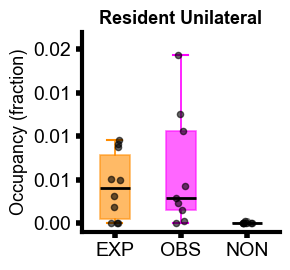

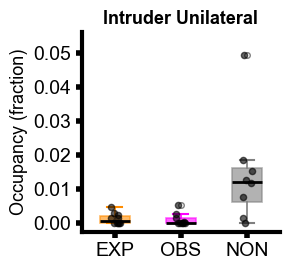

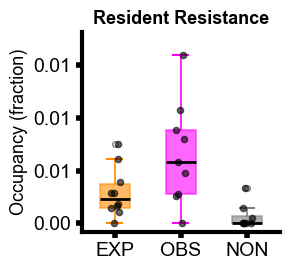

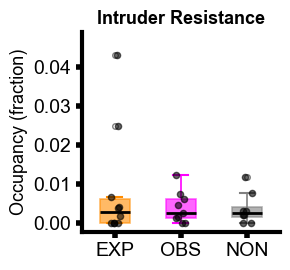

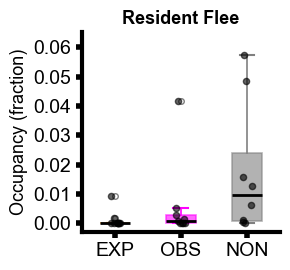


Occupancy statistics — normality -> variance -> omnibus (ANOVA/Welch ANOVA/KW) -> posthoc (t-test/Welch t-test/Brunner-Munzel), FDR-BH within behavior

resident_unilateral
  Normality passed: False   Equal variances: False   Levene p: 0.0250
  Omnibus: Kruskal-Wallis  stat=9.296  p=0.0096
  Comparison         Test                       Stat      df      p_raw     p_corr   Sig   n1   n2
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  EXP vs OBS        Brunner-Munzel            0.421     n/a     0.6797     0.6797         10    9
  EXP vs NON        Brunner-Munzel           -3.170     n/a     0.0098     0.0147     *   10    8
  OBS vs NON        Brunner-Munzel           -5.770     n/a     0.0002     0.0007   ***    9    8

intruder_unilateral
  Normality passed: False   Equal variances: False   Levene p: 0.0256
  Omnibus: Kruskal-Wallis  stat=10.315  p=0.0058
  Comparison         Test                       Stat      df      p_raw  

In [38]:
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, f_oneway, brunnermunzel, ttest_ind, levene, bartlett
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from matplotlib.ticker import FormatStrFormatter

matplotlib.rcParams['font.family'] = 'Arial'

GROUP_ORDER  = ['EXP', 'OBS', 'NON']
GROUP_COLORS = {'EXP': 'darkorange', 'OBS': 'magenta', 'NON': 'gray'}
BEHAVIORS    = list(ALL_BEHAVIOR_GROUPS.keys())
FPS          = 40

# ── Compute per-animal occupancy ───────────────────────────────────────────────
def compute_occupancy(session_dfs):
    records = []
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append(df)

    for (animal, group), dfs in animal_sessions.items():
        for beh in BEHAVIORS:
            sess_occ = []
            for df in dfs:
                n_total  = len(df)
                n_active = df[beh].sum()
                sess_occ.append(n_active / n_total if n_total > 0 else np.nan)
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'occupancy': np.nanmean(sess_occ),
            })

    return pd.DataFrame(records)

occ_df = compute_occupancy(session_dfs)

def format_p(p):
    if p is None or np.isnan(p): return 'n/a'
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001:     return '***'
    if p < 0.01:      return '**'
    if p < 0.05:      return '*'
    return ''

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

# ── Omnibus + posthoc, normality + variance gated ─────────────────────────────
def run_omnibus_and_posthoc(groups_data, group_names, alpha=0.05, variance_alpha=0.05):
    """
    1) Normality (Shapiro, per group)
    2) Variance (Levene always; Bartlett too if all normal)
    3) Omnibus: ANOVA (normal+equal var) / Welch ANOVA (normal+unequal var)
       / Kruskal-Wallis (non-normal)
    4) Posthoc (all pairs, gated by omnibus p<=0.05): t-test / Welch t-test
       / Brunner-Munzel, FDR-BH within region across pairs
    """
    valid_groups = [g for g in groups_data if len(g) >= 3]

    if len(valid_groups) < 2:
        return {'omnibus_test': 'insufficient data', 'omnibus_statistic': np.nan,
                'omnibus_p': np.nan, 'normality_passed': None, 'equal_variances': None,
                'posthoc': []}

    # ── 1. Normality ────────────────────────────────────────────────────────────
    norm_ps = [shapiro(g)[1] for g in valid_groups]
    normality_passed = all(p > alpha for p in norm_ps)

    # ── 2. Variance ───────────────────────────────────────────────────────────────
    levene_stat, levene_p = levene(*valid_groups)
    equal_variances = levene_p > variance_alpha
    bartlett_p = np.nan
    if normality_passed:
        bartlett_stat, bartlett_p = bartlett(*valid_groups)
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    # ── 3. Omnibus ────────────────────────────────────────────────────────────────
    df_combined = pd.DataFrame({
        'Activity': np.concatenate(valid_groups),
        'Group': np.concatenate([[str(i)]*len(g) for i, g in enumerate(valid_groups)]),
    })

    if normality_passed and equal_variances:
        model = sm.OLS.from_formula('Activity ~ C(Group)', data=df_combined).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        omni_stat, omni_p = anova_table['F'][0], anova_table['PR(>F)'][0]
        omni_test, pairwise_test = 'ANOVA', 't-test'
    elif normality_passed and not equal_variances:
        omni_stat, omni_p = f_oneway(*valid_groups)
        omni_test, pairwise_test = 'Welch ANOVA', 'Welch t-test'
    else:
        omni_stat, omni_p = kruskal(*valid_groups)
        omni_test, pairwise_test = 'Kruskal-Wallis', 'Brunner-Munzel'

    # ── 4. Posthoc (gated by omnibus p <= 0.05) ────────────────────────────────────
    pairs = [(i, j) for i in range(len(group_names)) for j in range(i+1, len(group_names))]
    raw_p, stats_, dfs_ = [], [], []

    for i, j in pairs:
        a, b = groups_data[i], groups_data[j]
        if omni_p <= 0.05 and len(a) >= 2 and len(b) >= 2:
            if pairwise_test == 't-test':
                s, p = ttest_ind(a, b, equal_var=True)
            elif pairwise_test == 'Welch t-test':
                s, p = ttest_ind(a, b, equal_var=False)
            else:
                s, p = brunnermunzel(a, b, alternative='two-sided')
            d = compute_df_for_test(pairwise_test, a, b)
        else:
            s, p, d = np.nan, np.nan, np.nan
        raw_p.append(p)
        stats_.append(s)
        dfs_.append(d)

    corrected = np.full(len(raw_p), np.nan)
    valid_idx = [idx for idx, p in enumerate(raw_p) if not np.isnan(p)]
    if valid_idx:
        _, corr, _, _ = multipletests([raw_p[idx] for idx in valid_idx], method='fdr_bh')
        for rank, idx in enumerate(valid_idx):
            corrected[idx] = corr[rank]

    posthoc = []
    for idx, (i, j) in enumerate(pairs):
        posthoc.append({
            'group1': group_names[i], 'group2': group_names[j],
            'test': pairwise_test if not np.isnan(raw_p[idx]) else 'n/a (omnibus n.s.)',
            'stat': stats_[idx], 'df': dfs_[idx],
            'p_raw': raw_p[idx], 'p_corr': corrected[idx],
            'n1': len(groups_data[i]), 'n2': len(groups_data[j]),
        })

    return {
        'omnibus_test': omni_test, 'omnibus_statistic': omni_stat, 'omnibus_p': omni_p,
        'normality_passed': normality_passed, 'normality_ps': norm_ps,
        'equal_variances': equal_variances, 'levene_p': levene_p, 'bartlett_p': bartlett_p,
        'posthoc': posthoc,
    }

# ── Plot ───────────────────────────────────────────────────────────────────────
def plot_occupancy_behavior(occ_df, behavior, ax,
                             axis_linewidth=1.5,
                             tick_length=4,
                             tick_width=1.5):

    beh_df = occ_df[occ_df['behavior'] == behavior]

    groups_data = [
        beh_df[beh_df['group'] == g]['occupancy'].dropna().values
        for g in GROUP_ORDER
    ]

    stat_result = run_omnibus_and_posthoc(groups_data, GROUP_ORDER)
    posthoc     = stat_result['posthoc']

    # ── Boxplot ──
    positions = np.arange(len(GROUP_ORDER))
    for pi, (g, pts) in enumerate(zip(GROUP_ORDER, groups_data)):
        color = GROUP_COLORS[g]
        if len(pts) == 0:
            continue
        ax.boxplot(pts,
                   positions=[pi], widths=0.45, patch_artist=True,
                   showfliers=True,
                   medianprops=dict(color='black', linewidth=2),
                   boxprops=dict(facecolor=color, alpha=0.6,
                                 linewidth=1.2, edgecolor=color),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.5),
                   flierprops=dict(marker='o', color=color,
                                   markeredgecolor='black',
                                   markersize=4, alpha=0.5))
        jitter = np.random.default_rng(42 + pi).uniform(-0.08, 0.08, size=len(pts))
        ax.scatter(np.full(len(pts), pi) + jitter, pts,
                   color='black', s=20, alpha=0.6, zorder=5)

    # ── Significance brackets ──
    ax.autoscale()
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.08)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    # y_max  = ax.get_ylim()[1]
    # step   = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
    # for level, res in enumerate(posthoc):
    #     sig = get_sig(res['p_corr'])
    #     if not sig:
    #         continue
    #     g1_idx = GROUP_ORDER.index(res['group1'])
    #     g2_idx = GROUP_ORDER.index(res['group2'])
    #     y_br   = y_max + step * (level + 1)
    #     ax.plot([g1_idx, g2_idx], [y_br, y_br], color='black', linewidth=2)
    #     ax.plot([g1_idx, g1_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
    #     ax.plot([g2_idx, g2_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
    #     ax.text((g1_idx + g2_idx) / 2, y_br, sig,
    #             ha='center', va='bottom', fontsize=13,
    #             fontweight='bold', fontfamily='Arial')

    # ── Formatting ──
    ax.set_xticks(positions)
    ax.set_xticklabels(GROUP_ORDER, fontsize=14, fontfamily='Arial')
    ax.set_ylabel('Occupancy (fraction)', fontsize=13, fontfamily='Arial')
    ax.set_title(behavior.replace('_', ' ').title(),
                 fontsize=13, fontweight='bold', fontfamily='Arial')

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(14)

    for spine in ax.spines.values():
        spine.set_linewidth(axis_linewidth)

    ax.tick_params(axis='both', length=tick_length, width=tick_width)

    sns.despine(ax=ax)
    return stat_result


# ── One figure per behavior ────────────────────────────────────────────────────
all_stats = {}
for beh in BEHAVIORS:
    fig, ax = plt.subplots(figsize=(3, 2.8))
    stat_result = plot_occupancy_behavior(
        occ_df, beh, ax,
        axis_linewidth=3,
        tick_length=4,
        tick_width=4,
    )
    all_stats[beh] = stat_result
    plt.tight_layout()
    plt.savefig(f'.\\figures\\fig1_occupancies_{beh}.svg', dpi=300)
    plt.show()
    plt.close()

# ── Print summary table ────────────────────────────────────────────────────────
print(f'\n{"="*135}')
print(f'Occupancy statistics — normality -> variance -> omnibus (ANOVA/Welch ANOVA/KW) '
      f'-> posthoc (t-test/Welch t-test/Brunner-Munzel), FDR-BH within behavior')
print(f'{"="*135}')

for beh, s in all_stats.items():
    omni_p_s    = format_p(s['omnibus_p'])
    omni_stat_s = f'{s["omnibus_statistic"]:.3f}' if not np.isnan(s['omnibus_statistic']) else 'n/a'
    norm_str    = 'n/a' if s['normality_passed'] is None else str(s['normality_passed'])
    var_str     = 'n/a' if s['equal_variances'] is None else str(s['equal_variances'])
    levene_str  = format_p(s.get('levene_p', np.nan))

    print(f'\n{beh}')
    print(f'  Normality passed: {norm_str}   Equal variances: {var_str}   Levene p: {levene_str}')
    print(f'  Omnibus: {s["omnibus_test"]}  stat={omni_stat_s}  p={omni_p_s}')
    print(f'  {"Comparison":<18} {"Test":<20} {"Stat":>10} {"df":>7} '
          f'{"p_raw":>10} {"p_corr":>10} {"Sig":>5} '
          f'{"n1":>4} {"n2":>4}')
    print(f'  {"─"*100}')
    for ph in s['posthoc']:
        sig    = get_sig(ph['p_corr'])
        stat_s = f'{ph["stat"]:>10.3f}' if not np.isnan(ph['stat']) else '       n/a'
        df_s   = f'{ph["df"]:.1f}'      if not np.isnan(ph['df'])   else 'n/a'
        p_r_s  = format_p(ph['p_raw'])
        p_c_s  = format_p(ph['p_corr'])
        print(f'  {ph["group1"]} vs {ph["group2"]:<10} {ph["test"]:<20} '
              f'{stat_s} {df_s:>7} {p_r_s:>10} {p_c_s:>10} {sig:>5} '
              f'{ph["n1"]:>4} {ph["n2"]:>4}')

In [20]:
def build_occupancy_source_data(behavior_label):
    available = occ_df['behavior'].unique()
    assert behavior_label in available, (
        f"'{behavior_label}' not found in occ_df['behavior']. "
        f"Available keys: {sorted(available)}"
    )

    beh_df = occ_df[occ_df['behavior'] == behavior_label]
    groups_data = [beh_df[beh_df['group'] == g]['occupancy'].dropna().values
                   for g in GROUP_ORDER]

    stat_result = run_omnibus_and_posthoc(groups_data, GROUP_ORDER)
    posthoc_lookup = {(ph['group1'], ph['group2']): ph for ph in stat_result['posthoc']}

    rows = []
    for g, pts in zip(GROUP_ORDER, groups_data):
        for v in pts:
            row = {
                'behavior': behavior_label,
                'group': g,
                'occupancy': v,
                'omnibus_test': stat_result['omnibus_test'],
                'omnibus_stat': stat_result['omnibus_statistic'],
                'omnibus_p': stat_result['omnibus_p'],
            }
            for (g1, g2), ph in posthoc_lookup.items():
                key = f'{g1}_vs_{g2}'
                row[f'{key}_test']  = ph['test']
                row[f'{key}_stat']  = ph['stat']
                row[f'{key}_df']    = ph['df']
                row[f'{key}_p_raw'] = ph['p_raw']
                row[f'{key}_p_fdr'] = ph['p_corr']
            rows.append(row)

    return pd.DataFrame(rows)

# ── 1e: resident unilateral (left) / resident resistance (right) ─────────────
sourceData_1e = pd.concat([
    build_occupancy_source_data('resident_unilateral').assign(panel='left'),
    build_occupancy_source_data('resident_resistance').assign(panel='right'),
], ignore_index=True)
sourceData_1e.to_csv('./sourceData/1e.csv', index=False)

# ── 1g: intruder unilateral (left) / intruder resistance (right) ─────────────
sourceData_1g = pd.concat([
    build_occupancy_source_data('intruder_unilateral').assign(panel='left'),
    build_occupancy_source_data('intruder_resistance').assign(panel='right'),
], ignore_index=True)
sourceData_1g.to_csv('./sourceData/1g.csv', index=False)

# ── ED1e (left): resident flee ────────────────────────────────────────────────
sourceData_ED1e_left = build_occupancy_source_data('resident_flee')
sourceData_ED1e_left.to_csv('./sourceData/ED1e_left.csv', index=False)

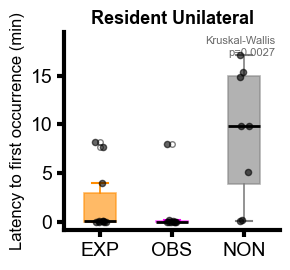


── resident_unilateral ──
  Normality passed: False   Equal variances: False   Levene p: 0.0315
  Omnibus: Kruskal-Wallis  stat=11.862  p=0.0027
  Comparison         Test                       Stat      df      p_raw     p_corr   Sig   n1   n2
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  EXP vs OBS        Brunner-Munzel           -1.054     n/a     0.3082     0.3082         10    9
  EXP vs NON        Brunner-Munzel            5.543     n/a  4.579e-05  6.868e-05   ***   10    8
  OBS vs NON        Brunner-Munzel            7.264     n/a  3.453e-06  1.036e-05   ***    9    8


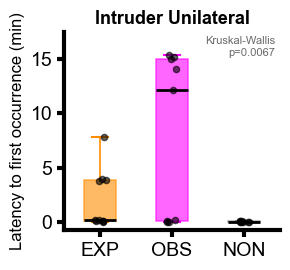


── intruder_unilateral ──
  Normality passed: False   Equal variances: False   Levene p: 0.0018
  Omnibus: Kruskal-Wallis  stat=10.011  p=0.0067
  Comparison         Test                       Stat      df      p_raw     p_corr   Sig   n1   n2
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  EXP vs OBS        Brunner-Munzel            1.047     n/a     0.3220     0.3220         10    9
  EXP vs NON        Brunner-Munzel           -5.543     n/a  4.579e-05     0.0001   ***   10    8
  OBS vs NON        Brunner-Munzel           -3.947     n/a     0.0016     0.0023    **    9    8


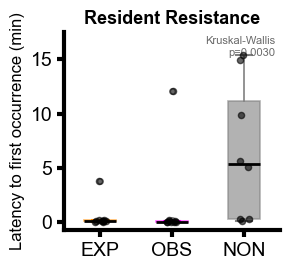


── resident_resistance ──
  Normality passed: False   Equal variances: False   Levene p: 0.0133
  Omnibus: Kruskal-Wallis  stat=11.608  p=0.0030
  Comparison         Test                       Stat      df      p_raw     p_corr   Sig   n1   n2
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  EXP vs OBS        Brunner-Munzel           -0.912     n/a     0.3830     0.3830         10    9
  EXP vs NON        Brunner-Munzel            6.833     n/a  8.050e-06  2.415e-05   ***   10    8
  OBS vs NON        Brunner-Munzel            4.657     n/a     0.0010     0.0016    **    9    8


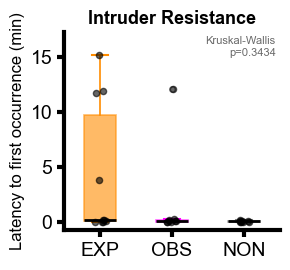


── intruder_resistance ──
  Normality passed: False   Equal variances: True   Levene p: 0.1290
  Omnibus: Kruskal-Wallis  stat=2.138  p=0.3434
  Comparison         Test                       Stat      df      p_raw     p_corr   Sig   n1   n2
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  EXP vs OBS        n/a (omnibus n.s.)          n/a     n/a        n/a        n/a         10    9
  EXP vs NON        n/a (omnibus n.s.)          n/a     n/a        n/a        n/a         10    8
  OBS vs NON        n/a (omnibus n.s.)          n/a     n/a        n/a        n/a          9    8


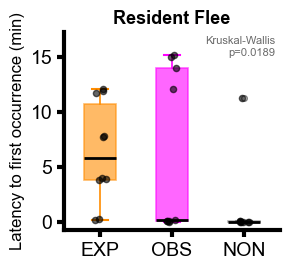


── resident_flee ──
  Normality passed: False   Equal variances: True   Levene p: 0.1554
  Omnibus: Kruskal-Wallis  stat=7.935  p=0.0189
  Comparison         Test                       Stat      df      p_raw     p_corr   Sig   n1   n2
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  EXP vs OBS        Brunner-Munzel           -0.257     n/a     0.8035     0.8035         10    9
  EXP vs NON        Brunner-Munzel           -4.606     n/a     0.0019     0.0058    **   10    8
  OBS vs NON        Brunner-Munzel           -2.139     n/a     0.0501     0.0752          9    8


In [14]:
def compute_latency_to_first_global(session_dfs, fps=40):
    records = []
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append((session, df))

    for (animal, group), sess_list in animal_sessions.items():
        sess_list = sorted(sess_list, key=lambda x: x[0])
        concat_df = pd.concat([df for _, df in sess_list], ignore_index=True)
        for beh in BEHAVIORS:
            active_frames = np.where(concat_df[beh].values == 1)[0]
            latency       = active_frames[0] / fps if len(active_frames) > 0 else len(concat_df)
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'latency_s': latency,
                'latency_m': latency / 40 / 60,
            })

    return pd.DataFrame(records)

lat_global_df = compute_latency_to_first_global(session_dfs, fps=FPS)

# ── Plot ───────────────────────────────────────────────────────────────────────

for beh in BEHAVIORS:
    fig, ax = plt.subplots(figsize=(3, 2.8))
    beh_df  = lat_global_df[lat_global_df['behavior'] == beh]

    groups_data = [
        beh_df[beh_df['group'] == g]['latency_m'].dropna().values
        for g in GROUP_ORDER
    ]

    stat_result = run_omnibus_and_posthoc(groups_data, GROUP_ORDER)
    posthoc     = stat_result['posthoc']

    # Boxplots + dots
    for pi, (g, pts) in enumerate(zip(GROUP_ORDER, groups_data)):
        color = GROUP_COLORS[g]
        if len(pts) == 0:
            continue
        ax.boxplot(pts,
                   positions=[pi], widths=0.45, patch_artist=True,
                   showfliers=True,
                   medianprops=dict(color='black', linewidth=2),
                   boxprops=dict(facecolor=color, alpha=0.6,
                                 linewidth=1.2, edgecolor=color),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.5),
                   flierprops=dict(marker='o', color=color,
                                   markeredgecolor='black',
                                   markersize=4, alpha=0.5))
        jitter = np.random.default_rng(42 + pi).uniform(-0.08, 0.08, size=len(pts))
        ax.scatter(np.full(len(pts), pi) + jitter, pts,
                   color='black', s=20, alpha=0.6, zorder=5)

    # Significance brackets
    ax.autoscale()

    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.08)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    # y_max = ax.get_ylim()[1]
    # step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
    # for level, res in enumerate(posthoc):
    #     sig = get_sig(res['p_corr'])
    #     if not sig:
    #         continue
    #     g1_idx = GROUP_ORDER.index(res['group1'])
    #     g2_idx = GROUP_ORDER.index(res['group2'])
    #     y_br   = y_max + step * (level + 1)
    #     ax.plot([g1_idx, g2_idx], [y_br, y_br], color='black', linewidth=1.2)
    #     ax.plot([g1_idx, g1_idx], [y_br - step*0.2, y_br], color='black', linewidth=1.2)
    #     ax.plot([g2_idx, g2_idx], [y_br - step*0.2, y_br], color='black', linewidth=1.2)
    #     ax.text((g1_idx + g2_idx) / 2, y_br, sig,
    #             ha='center', va='bottom', fontsize=13,
    #             fontweight='bold', fontfamily='Arial')

    # Formatting
    ax.set_xticks(np.arange(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontsize=13, fontfamily='Arial')
    ax.set_ylabel('Latency to first occurrence (min)',
                  fontsize=12, fontfamily='Arial')
    ax.set_title(beh.replace('_', ' ').title(),
                 fontsize=13, fontweight='bold', fontfamily='Arial')

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(14)

    for spine in ax.spines.values():
        spine.set_linewidth(3)

    ax.tick_params(axis='both', length=5, width=3)

    p_str = format_p(stat_result['omnibus_p'])
    ax.text(0.98, 0.98, f'{stat_result["omnibus_test"]}\np={p_str}',
            transform=ax.transAxes, fontsize=8, fontfamily='Arial',
            ha='right', va='top', color='dimgray')

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f'./figures/fig1_latency_global_{beh}.svg', dpi=300)
    plt.show()
    plt.close()

    omni_stat_s = f'{stat_result["omnibus_statistic"]:.3f}' \
                  if not np.isnan(stat_result['omnibus_statistic']) else 'n/a'
    norm_str    = 'n/a' if stat_result['normality_passed'] is None else str(stat_result['normality_passed'])
    var_str     = 'n/a' if stat_result['equal_variances'] is None else str(stat_result['equal_variances'])
    levene_str  = format_p(stat_result.get('levene_p', np.nan))

    print(f'\n── {beh} ──')
    print(f'  Normality passed: {norm_str}   Equal variances: {var_str}   Levene p: {levene_str}')
    print(f'  Omnibus: {stat_result["omnibus_test"]}  stat={omni_stat_s}  p={p_str}')
    print(f'  {"Comparison":<18} {"Test":<20} {"Stat":>10} {"df":>7} '
          f'{"p_raw":>10} {"p_corr":>10} {"Sig":>5} '
          f'{"n1":>4} {"n2":>4}')
    print(f'  {"─"*100}')
    for ph in posthoc:
        sig    = get_sig(ph['p_corr'])
        stat_s = f'{ph["stat"]:>10.3f}' if not np.isnan(ph['stat']) else '       n/a'
        df_s   = f'{ph["df"]:.1f}'      if not np.isnan(ph['df'])   else 'n/a'
        p_r_s  = format_p(ph['p_raw'])
        p_c_s  = format_p(ph['p_corr'])
        print(f'  {ph["group1"]} vs {ph["group2"]:<10} {ph["test"]:<20} '
              f'{stat_s} {df_s:>7} {p_r_s:>10} {p_c_s:>10} {sig:>5} '
              f'{ph["n1"]:>4} {ph["n2"]:>4}')

In [21]:
def build_latency_source_data(behavior_label):
    available = lat_global_df['behavior'].unique()
    assert behavior_label in available, (
        f"'{behavior_label}' not found in lat_global_df['behavior']. "
        f"Available keys: {sorted(available)}"
    )

    beh_df = lat_global_df[lat_global_df['behavior'] == behavior_label]
    groups_data = [beh_df[beh_df['group'] == g]['latency_m'].dropna().values
                   for g in GROUP_ORDER]

    stat_result = run_omnibus_and_posthoc(groups_data, GROUP_ORDER)
    posthoc_lookup = {(ph['group1'], ph['group2']): ph for ph in stat_result['posthoc']}

    rows = []
    for g, pts in zip(GROUP_ORDER, groups_data):
        for v in pts:
            row = {
                'behavior': behavior_label,
                'group': g,
                'latency_min': v,
                'omnibus_test': stat_result['omnibus_test'],
                'omnibus_stat': stat_result['omnibus_statistic'],
                'omnibus_p': stat_result['omnibus_p'],
            }
            for (g1, g2), ph in posthoc_lookup.items():
                key = f'{g1}_vs_{g2}'
                row[f'{key}_test']  = ph['test']
                row[f'{key}_stat']  = ph['stat']
                row[f'{key}_df']    = ph['df']
                row[f'{key}_p_raw'] = ph['p_raw']
                row[f'{key}_p_fdr'] = ph['p_corr']
            rows.append(row)

    return pd.DataFrame(rows)

# ── 1f: resident unilateral (left) / resident resistance (right) ─────────────
sourceData_1f = pd.concat([
    build_latency_source_data('resident_unilateral').assign(panel='left'),
    build_latency_source_data('resident_resistance').assign(panel='right'),
], ignore_index=True)
sourceData_1f.to_csv('./sourceData/1f.csv', index=False)

# ── 1h: intruder unilateral (left) / intruder resistance (right) ─────────────
sourceData_1h = pd.concat([
    build_latency_source_data('intruder_unilateral').assign(panel='left'),
    build_latency_source_data('intruder_resistance').assign(panel='right'),
], ignore_index=True)
sourceData_1h.to_csv('./sourceData/1h.csv', index=False)

# ── ED1e (right): resident flee ───────────────────────────────────────────────
sourceData_ED1e_right = build_latency_source_data('resident_flee')
sourceData_ED1e_right.to_csv('./sourceData/ED1e_right.csv', index=False)


Animal       Group  Conflict(s)   Resident Unilatera  Intruder Unilatera  Resident Resistanc  Intruder Resistanc  
--------------------------------------------------------------------------------
3095         EXP    15.10         0.000              0.045              0.189              0.767              
3096         EXP    0.72          1.000              0.000              0.000              0.000              
3097         EXP    6.95          0.640              0.000              0.076              0.284              
30B          EXP    10.75         0.000              0.000              0.037              0.963              
30L          EXP    4.67          0.000              0.155              0.144              0.706              
4013         EXP    2.52          0.465              0.000              0.366              0.168              
4014         EXP    7.75          0.835              0.003              0.168              0.000              
4015         EXP    16.18 

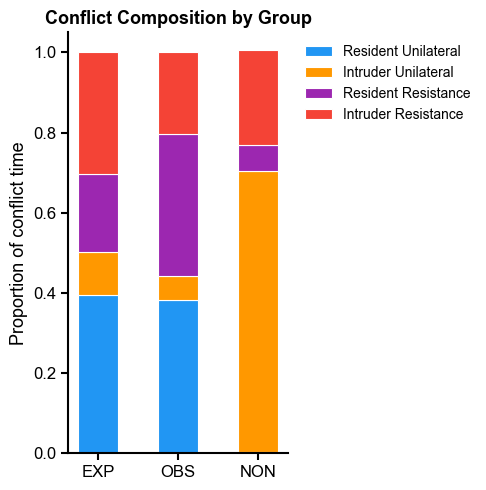

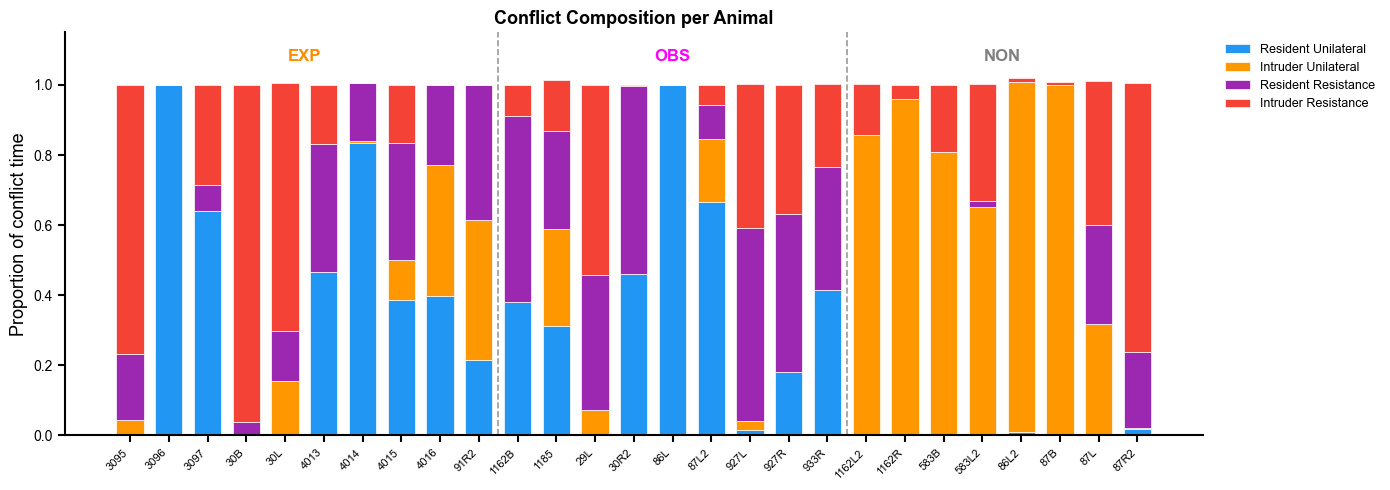

In [17]:
# ── Conflict behavior composition ─────────────────────────────────────────────
CONFLICT_BEHAVIORS = [
    'resident_unilateral',
    'intruder_unilateral',
    'resident_resistance',
    'intruder_resistance',
]

CONFLICT_COLORS = {
    'resident_unilateral': '#2196F3',   # blue
    'intruder_unilateral': '#FF9800',   # orange
    'resident_resistance': '#9C27B0',   # purple
    'intruder_resistance': '#F44336',   # red
}

CONFLICT_LABELS = {
    'resident_unilateral': 'Resident Unilateral',
    'intruder_unilateral': 'Intruder Unilateral',
    'resident_resistance': 'Resident Resistance',
    'intruder_resistance': 'Intruder Resistance',
}

def compute_conflict_proportions(session_dfs):
    """
    For each animal, concatenate all sessions and compute the proportion
    of total conflict frames occupied by each behavior type.
    Returns DataFrame: animal, group, + one column per conflict behavior (proportion).
    """
    records = []

    # Group sessions by animal
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append((session, df))

    for (animal, group), sess_list in animal_sessions.items():
        sess_list  = sorted(sess_list, key=lambda x: x[0])
        concat_df  = pd.concat([df for _, df in sess_list], ignore_index=True)

        # Total conflict frames = any of the 4 behaviors active
        conflict_mask  = np.zeros(len(concat_df), dtype=bool)
        for beh in CONFLICT_BEHAVIORS:
            conflict_mask |= (concat_df[beh].values == 1)
        total_conflict = conflict_mask.sum()

        if total_conflict == 0:
            # Animal had no conflict at all — all proportions NaN
            row = {'animal': animal, 'group': group, 'total_conflict_s': 0}
            for beh in CONFLICT_BEHAVIORS:
                row[beh] = np.nan
            records.append(row)
            continue

        row = {
            'animal':           animal,
            'group':            group,
            'total_conflict_s': total_conflict / FPS,
        }
        for beh in CONFLICT_BEHAVIORS:
            n_frames   = concat_df[beh].sum()
            row[beh]   = n_frames / total_conflict  # proportion within conflict
        records.append(row)

    return pd.DataFrame(records)

conf_df = compute_conflict_proportions(session_dfs)

# ── Print per-animal summary ───────────────────────────────────────────────────
print(f'\n{"="*80}')
print(f'{"Animal":<12} {"Group":<6} {"Conflict(s)":<14}', end='')
for beh in CONFLICT_BEHAVIORS:
    print(f'{CONFLICT_LABELS[beh][:18]:<20}', end='')
print()
print('-'*80)
for _, row in conf_df.sort_values(['group','animal']).iterrows():
    print(f'{row["animal"]:<12} {row["group"]:<6} {row["total_conflict_s"]:<14.2f}', end='')
    for beh in CONFLICT_BEHAVIORS:
        val = row[beh]
        print(f'{val:.3f}{"":14}' if not np.isnan(val) else f'{"NaN":<20}', end='')
    print()

# ── Per-group mean proportions ─────────────────────────────────────────────────
def group_mean_proportions(conf_df):
    records = []
    for group in GROUP_ORDER:
        gdf = conf_df[conf_df['group'] == group]
        row = {'group': group}
        for beh in CONFLICT_BEHAVIORS:
            row[f'{beh}_mean'] = gdf[beh].dropna().mean()
            row[f'{beh}_sem']  = gdf[beh].dropna().sem()
            row[f'{beh}_n']    = gdf[beh].dropna().count()
        records.append(row)
    return pd.DataFrame(records)

group_props = group_mean_proportions(conf_df)

# ── Figure 1: Stacked bar — group mean proportions ────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

x      = np.arange(len(GROUP_ORDER))
bottom = np.zeros(len(GROUP_ORDER))

for beh in CONFLICT_BEHAVIORS:
    means = np.array([
        group_props.loc[group_props['group'] == g, f'{beh}_mean'].values[0]
        for g in GROUP_ORDER
    ])
    sems = np.array([
        group_props.loc[group_props['group'] == g, f'{beh}_sem'].values[0]
        for g in GROUP_ORDER
    ])
    bars = ax.bar(x, means, bottom=bottom, color=CONFLICT_COLORS[beh],
                  label=CONFLICT_LABELS[beh], width=0.5, edgecolor='white',
                  linewidth=0.8)
    bottom += np.nan_to_num(means)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER, fontsize=14, fontfamily='Arial')
ax.set_ylabel('Proportion of conflict time', fontsize=13, fontfamily='Arial')
ax.set_title('Conflict Composition by Group', fontsize=13,
             fontweight='bold', fontfamily='Arial')
ax.set_ylim(0, 1.05)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
    tick.set_fontsize(12)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(length=5, width=1.5)
leg = ax.legend(fontsize=10, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
for text in leg.get_texts():
    text.set_fontfamily('Arial')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('.\\figures\\fig1_conflict_composition_stacked.svg', dpi=300)
plt.show()

# ── Figure 2: Per-animal stacked bars, grouped by EXP/OBS/NON ────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Sort animals: EXP first, then OBS, then NON
conf_sorted = pd.concat([
    conf_df[conf_df['group'] == g].sort_values('animal')
    for g in GROUP_ORDER
]).reset_index(drop=True)

x_pos  = np.arange(len(conf_sorted))
bottom = np.zeros(len(conf_sorted))

for beh in CONFLICT_BEHAVIORS:
    vals = conf_sorted[beh].fillna(0).values
    ax.bar(x_pos, vals, bottom=bottom, color=CONFLICT_COLORS[beh],
           label=CONFLICT_LABELS[beh], width=0.7, edgecolor='white', linewidth=0.5)
    bottom += vals

# Group dividers and labels
group_boundaries = []
for g in GROUP_ORDER:
    idxs = conf_sorted[conf_sorted['group'] == g].index.tolist()
    if idxs:
        group_boundaries.append((idxs[0], idxs[-1], g))

for start, end, g in group_boundaries:
    mid = (start + end) / 2
    ax.text(mid, 1.06, g, ha='center', va='bottom', fontsize=12,
            fontweight='bold', fontfamily='Arial', color=GROUP_COLORS[g])
    if start > 0:
        ax.axvline(start - 0.5, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

ax.set_xticks(x_pos)
ax.set_xticklabels(conf_sorted['animal'].values, fontsize=8,
                   fontfamily='Arial', rotation=45, ha='right')
ax.set_ylabel('Proportion of conflict time', fontsize=13, fontfamily='Arial')
ax.set_title('Conflict Composition per Animal', fontsize=13,
             fontweight='bold', fontfamily='Arial')
ax.set_ylim(0, 1.15)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(length=5, width=1.5)
leg = ax.legend(fontsize=9, frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
for text in leg.get_texts():
    text.set_fontfamily('Arial')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('.\\figures\\fig1_conflict_composition_per_animal.svg', dpi=300)
plt.show()

In [18]:
rows = []
for beh in CONFLICT_BEHAVIORS:
    for g in GROUP_ORDER:
        mean_val = group_props.loc[group_props['group'] == g, f'{beh}_mean'].values[0]
        sem_val  = group_props.loc[group_props['group'] == g, f'{beh}_sem'].values[0]
        n_val    = group_props.loc[group_props['group'] == g, f'{beh}_n'].values[0]
        rows.append({
            'group': g,
            'behavior': CONFLICT_LABELS[beh],
            'mean_proportion': mean_val,
            'sem': sem_val,
            'n': n_val,
        })

sourceData_1d_right = pd.DataFrame(rows)
sourceData_1d_right.to_csv('./sourceData/1d_right.csv', index=False)


TOTAL CONFLICT OCCUPANCY
  Normality passed: True   Equal variances: True   Levene p: 0.9934
  Omnibus: ANOVA  stat=0.053  p=0.9480
  Comparison         Test                       Stat      df      p_raw     p_corr   Sig   n1   n2
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  EXP vs OBS        n/a (omnibus n.s.)          n/a     n/a        n/a        n/a         10    9
  EXP vs NON        n/a (omnibus n.s.)          n/a     n/a        n/a        n/a         10    8
  OBS vs NON        n/a (omnibus n.s.)          n/a     n/a        n/a        n/a          9    8


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_35964\1589708235.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  omni_stat, omni_p = anova_table['F'][0], anova_table['PR(>F)'][0]


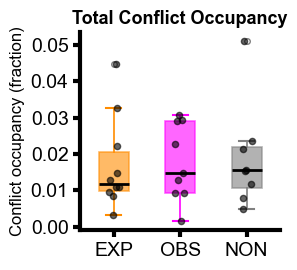

In [19]:
import scipy

# ── Add total conflict occupancy to conf_df ────────────────────────────────────
def compute_total_conflict_occupancy(session_dfs):
    """
    For each animal, total conflict occupancy =
    frames where ANY attack behavior is active / total frames across all sessions.
    """
    records = []
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append((session, df))

    for (animal, group), sess_list in animal_sessions.items():
        sess_list = sorted(sess_list, key=lambda x: x[0])
        concat_df = pd.concat([df for _, df in sess_list], ignore_index=True)

        conflict_mask = np.zeros(len(concat_df), dtype=bool)
        for beh in CONFLICT_BEHAVIORS:
            conflict_mask |= (concat_df[beh].values == 1)

        occupancy = conflict_mask.sum() / len(concat_df)
        records.append({
            'animal':   animal,
            'group':    group,
            'occupancy': occupancy,
        })

    return pd.DataFrame(records)

total_conf_occ = compute_total_conflict_occupancy(session_dfs)

# ── Stats ──────────────────────────────────────────────────────────────────────
groups_data = [
    total_conf_occ[total_conf_occ['group'] == g]['occupancy'].dropna().values
    for g in GROUP_ORDER
]

stat_result = run_omnibus_and_posthoc(groups_data, GROUP_ORDER)
posthoc     = stat_result['posthoc']

omni_stat_s = f'{stat_result["omnibus_statistic"]:.3f}' \
              if not np.isnan(stat_result['omnibus_statistic']) else 'n/a'
omni_p_s    = format_p(stat_result['omnibus_p'])
norm_str    = 'n/a' if stat_result['normality_passed'] is None else str(stat_result['normality_passed'])
var_str     = 'n/a' if stat_result['equal_variances'] is None else str(stat_result['equal_variances'])
levene_str  = format_p(stat_result.get('levene_p', np.nan))

print(f'\n{"="*100}')
print(f'TOTAL CONFLICT OCCUPANCY')
print(f'  Normality passed: {norm_str}   Equal variances: {var_str}   Levene p: {levene_str}')
print(f'  Omnibus: {stat_result["omnibus_test"]}  stat={omni_stat_s}  p={omni_p_s}')
print(f'{"="*100}')
print(f'  {"Comparison":<18} {"Test":<20} {"Stat":>10} {"df":>7} '
      f'{"p_raw":>10} {"p_corr":>10} {"Sig":>5} '
      f'{"n1":>4} {"n2":>4}')
print(f'  {"─"*100}')
for ph in posthoc:
    sig    = get_sig(ph['p_corr'])
    stat_s = f'{ph["stat"]:>10.3f}' if not np.isnan(ph['stat']) else '       n/a'
    df_s   = f'{ph["df"]:.1f}'      if not np.isnan(ph['df'])   else 'n/a'
    p_r_s  = format_p(ph['p_raw'])
    p_c_s  = format_p(ph['p_corr'])
    print(f'  {ph["group1"]} vs {ph["group2"]:<10} {ph["test"]:<20} '
          f'{stat_s} {df_s:>7} {p_r_s:>10} {p_c_s:>10} {sig:>5} '
          f'{ph["n1"]:>4} {ph["n2"]:>4}')
print(f'{"="*100}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3, 2.8))

for pi, (g, pts) in enumerate(zip(GROUP_ORDER, groups_data)):
    color = GROUP_COLORS[g]
    if len(pts) == 0:
        continue
    ax.boxplot(pts,
               positions=[pi], widths=0.45, patch_artist=True,
               showfliers=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.6,
                             linewidth=1.2, edgecolor=color),
               whiskerprops=dict(color=color, linewidth=1.2),
               capprops=dict(color=color, linewidth=1.5),
               flierprops=dict(marker='o', color=color,
                               markeredgecolor='black',
                               markersize=4, alpha=0.5))
    jitter = np.random.default_rng(42 + pi).uniform(-0.08, 0.08, size=len(pts))
    ax.scatter(np.full(len(pts), pi) + jitter, pts,
               color='black', s=20, alpha=0.6, zorder=5)

# Significance brackets
ax.autoscale()
y_max = ax.get_ylim()[1]
step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
for level, res in enumerate(posthoc):
    sig = get_sig(res['p_corr'])
    if not sig:
        continue
    g1_idx = GROUP_ORDER.index(res['group1'])
    g2_idx = GROUP_ORDER.index(res['group2'])
    y_br   = y_max + step * (level + 1)
    ax.plot([g1_idx, g2_idx], [y_br, y_br], color='black', linewidth=2)
    ax.plot([g1_idx, g1_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
    ax.plot([g2_idx, g2_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
    ax.text((g1_idx + g2_idx) / 2, y_br, sig,
            ha='center', va='bottom', fontsize=13,
            fontweight='bold', fontfamily='Arial')

ax.set_xticks(np.arange(len(GROUP_ORDER)))
ax.set_xticklabels(GROUP_ORDER, fontsize=14, fontfamily='Arial')
ax.set_ylabel('Conflict occupancy (fraction)', fontsize=12, fontfamily='Arial')
ax.set_title('Total Conflict Occupancy', fontsize=13,
             fontweight='bold', fontfamily='Arial')
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
    tick.set_fontsize(14)
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(length=5, width=3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('.\\figures\\fig1_total_conflict_occupancy.svg', dpi=300)
plt.show()

In [23]:
# ── Source data export: 1d_left ───────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

posthoc_lookup = {(ph['group1'], ph['group2']): ph for ph in stat_result['posthoc']}

rows = []
for g, pts in zip(GROUP_ORDER, groups_data):
    for v in pts:
        row = {
            'group': g,
            'conflict_occupancy': v,
            'omnibus_test': stat_result['omnibus_test'],
            'omnibus_stat': stat_result['omnibus_statistic'],
            'omnibus_p': stat_result['omnibus_p'],
        }
        for (g1, g2), ph in posthoc_lookup.items():
            key = f'{g1}_vs_{g2}'
            row[f'{key}_test']  = ph['test']
            row[f'{key}_stat']  = ph['stat']
            row[f'{key}_df']    = ph['df']
            row[f'{key}_p_raw'] = ph['p_raw']
            row[f'{key}_p_fdr'] = ph['p_corr']
        rows.append(row)

sourceData_1d_left = pd.DataFrame(rows)
sourceData_1d_left.to_csv('./sourceData/1d_left.csv', index=False)

In [22]:
# Save all dfs for future analysis

occ_df.to_pickle('hand-annotated_fight_occupancies.pickle')
total_conf_occ.to_pickle('hand-annotated_conflict_occupancies.pickle')

# Gq hand-scored behaviors

In [24]:
boris_dir = 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\'
boris_files = np.sort([boris_dir + x for x in os.listdir(boris_dir) if '.csv' in x and '._' not in x])
print('Sample boris files:')
print(boris_files)

Sample boris files:
['C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\77355B_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\77355R_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\82017L2_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\8605R_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\8606L_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\8606R2_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC1_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC2_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC3_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC4_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC5_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC6_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC7_d6_CNO_t1.csv']



=== 77355B_d6_CNO_t1.csv | 77355B | Vgat+/- | t1 ===
  Format A failed (Format A columns not found), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_attack_with_resistance' 'intruder_attack_with_resistance'
 'resident_unilateral_attack']
  resident_unilateral                37 frames  (0.93s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance               504 frames  (12.60s)
  intruder_resistance                71 frames  (1.77s)
  resident_flee                       0 frames  (0.00s)

=== 77355R_d6_CNO_t1.csv | 77355R | Vgat+/- | t1 ===
  Format A failed (Format A columns not found), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_attack_with_resistance' 'intruder_attack_with_resistance']
  resident_unilateral                 0 frames  (0.00s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance                73 frames  (1.82s)
  i

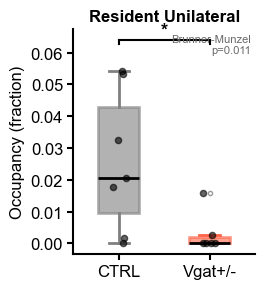

resident_unilateral: Brunner-Munzel p=0.0106  CTRL=0.0257  DREADD=0.0031


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


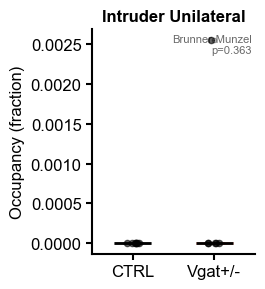

intruder_unilateral: Brunner-Munzel p=0.3632  CTRL=0.0000  DREADD=0.0004


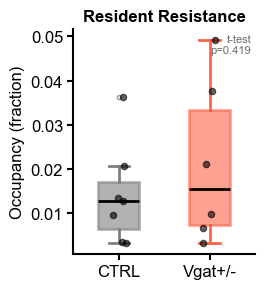

resident_resistance: t-test p=0.4195  CTRL=0.0142  DREADD=0.0213


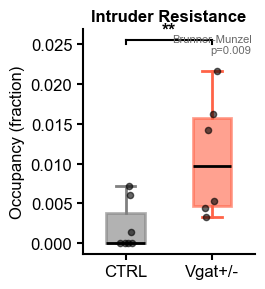

intruder_resistance: Brunner-Munzel p=0.0094  CTRL=0.0021  DREADD=0.0109


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


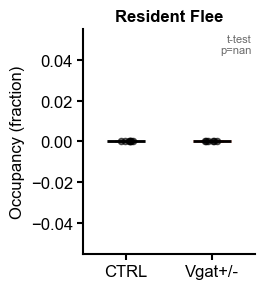

resident_flee: t-test p=nan  CTRL=0.0000  DREADD=0.0000


In [25]:
# ── Behavior constants (same as before) ───────────────────────────────────────
RESIDENT_UNILATERAL = ['resident_unilateral_attack']
INTRUDER_UNILATERAL = ['intruder_unilateral_attack']
RESIDENT_RESISTANCE = ['resident_attack_with_resistance', 'fight_from_resident_with_resistance']
INTRUDER_RESISTANCE = ['intruder_attack_with_resistance', 'fight_from_intruder_with_resistance']
RESIDENT_FLEE       = ['resident_flee']

ALL_BEHAVIOR_GROUPS = {
    'resident_unilateral': RESIDENT_UNILATERAL,
    'intruder_unilateral': INTRUDER_UNILATERAL,
    'resident_resistance': RESIDENT_RESISTANCE,
    'intruder_resistance': INTRUDER_RESISTANCE,
    'resident_flee':       RESIDENT_FLEE,
}

# ── Updated filename parser — handles CNO sessions ────────────────────────────
def parse_filename_cno(fname):
    """
    Parses filenames like:
      8605B_d6_CNO_t1.csv   -> animal=8605B,  group=CTRL, session=1
      GqC1_d6_CNO_t1.csv   -> animal=GqC1,   group=DREADD, session=1
    """
    base  = os.path.basename(fname).replace('.csv', '')
    match = re.match(r'^(.+?)_d\d+_CNO_t(\d+)$', base)
    if match:
        animal  = match.group(1)
        session = int(match.group(2))
        group   = 'CTRL' if animal.startswith('GqC') else 'Vgat+/-'
        return animal, session, group
    return None, None, None

# ── Load all CNO sessions ──────────────────────────────────────────────────────
def load_cno_sessions(boris_files, boris_fps=40):
    session_dfs = {}

    for path in boris_files:
        animal, session, group = parse_filename_cno(path)
        if animal is None:
            print(f'  Could not parse: {os.path.basename(path)}')
            continue

        print(f'\n=== {os.path.basename(path)} | {animal} | {group} | t{session} ===')
        behs = format_boris_new(path, boris_fps=boris_fps)

        if behs is None:
            print(f'  Skipping — could not parse.')
            continue

        n_frames = int(behs['Duration'].max()) - 2400

        arrays = {}
        for col_name, behavior_list in ALL_BEHAVIOR_GROUPS.items():
            col = np.zeros(n_frames, dtype=int)
            for beh in behavior_list:
                if beh in behs['Behavior'].values:
                    frames = extract_frames_from_boris(behs, beh)
                    if len(frames):
                        col[np.clip(frames, 0, n_frames - 1)] = 1
            arrays[col_name] = col

        df = pd.DataFrame(arrays)
        df.insert(0, 'animal',  animal)
        df.insert(1, 'group',   group)
        df.insert(2, 'session', session)
        df.insert(3, 'time_s',  np.arange(n_frames) / boris_fps)

        key = (animal, session, group)
        session_dfs[key] = df

        for col in ALL_BEHAVIOR_GROUPS:
            n = arrays[col].sum()
            print(f'  {col:<30} {n:>6} frames  ({n/boris_fps:.2f}s)')

    print(f'\n{"="*60}')
    print(f'Loaded {len(session_dfs)} sessions total.')
    return session_dfs

# ── Run ────────────────────────────────────────────────────────────────────────
cno_files = boris_files

cno_session_dfs = load_cno_sessions(cno_files, boris_fps=40)
cno_master_df   = pd.concat(cno_session_dfs.values(), ignore_index=True)

print(f'\nCNO master DataFrame: {cno_master_df.shape}')
print(cno_master_df.groupby('group')[['animal']].nunique())

# ── Occupancy per animal ───────────────────────────────────────────────────────
def compute_occupancy_cno(session_dfs):
    records = []
    for (animal, session, group), df in session_dfs.items():
        n_total = len(df)
        for beh in ALL_BEHAVIOR_GROUPS:
            n_active = df[beh].sum()
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'occupancy': n_active / n_total if n_total > 0 else np.nan,
            })
    return pd.DataFrame(records)

cno_occ_df = compute_occupancy_cno(cno_session_dfs)

# ── Plot — same boxplot style as before ───────────────────────────────────────
GROUP_ORDER_CNO  = ['CTRL', 'Vgat+/-']
GROUP_COLORS_CNO = {'CTRL': 'gray', 'Vgat+/-': 'tomato'}
BEHAVIORS        = list(ALL_BEHAVIOR_GROUPS.keys())

# os.makedirs('./figures/cno/', exist_ok=True)

for beh in BEHAVIORS:
    fig, ax = plt.subplots(figsize=(2.75, 3))
    beh_df  = cno_occ_df[cno_occ_df['behavior'] == beh]

    groups_data = [
        beh_df[beh_df['group'] == g]['occupancy'].dropna().values
        for g in GROUP_ORDER_CNO
    ]

    # Stats
    valid_groups = [g for g in groups_data if len(g) >= 2]
    if len(valid_groups) == 2:
        _, p_a = shapiro(groups_data[0]) if len(groups_data[0]) >= 3 else (None, 0)
        _, p_b = shapiro(groups_data[1]) if len(groups_data[1]) >= 3 else (None, 0)
        parametric = p_a > 0.05 and p_b > 0.05
        if parametric:
            _, p_val   = ttest_ind(groups_data[0], groups_data[1])
            test_label = 't-test'
        else:
            _, p_val   = brunnermunzel(groups_data[0], groups_data[1],
                                       alternative='two-sided')
            test_label = 'Brunner-Munzel'
    else:
        p_val, test_label = np.nan, 'n/a'

    # Boxplots
    positions = [1, 2]
    box = ax.boxplot(groups_data,
                     positions=positions,
                     patch_artist=True, widths=0.45,
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(marker='o', markersize=3,
                                     markeredgecolor='black', alpha=0.4))

    for patch, g in zip(box['boxes'], GROUP_ORDER_CNO):
        color = GROUP_COLORS_CNO[g]
        patch.set_facecolor(color); patch.set_edgecolor(color)
        patch.set_alpha(0.6);       patch.set_linewidth(2)
    for whisker, color in zip(box['whiskers'],
                               [GROUP_COLORS_CNO[g]
                                for g in GROUP_ORDER_CNO for _ in (0,1)]):
        whisker.set_color(color); whisker.set_linewidth(2)
    for cap, color in zip(box['caps'],
                           [GROUP_COLORS_CNO[g]
                            for g in GROUP_ORDER_CNO for _ in (0,1)]):
        cap.set_color(color); cap.set_linewidth(2)

    # Individual dots
    for j, (data, g) in enumerate(zip(groups_data, GROUP_ORDER_CNO)):
        jitter = np.random.default_rng(42+j).uniform(-0.08, 0.08, size=len(data))
        ax.scatter(np.full(len(data), positions[j]) + jitter,
                   data, color='black', s=20, alpha=0.6, zorder=5)

    # Significance bracket
    ax.autoscale()
    y_max = ax.get_ylim()[1]
    step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
    sig   = get_sig(p_val) if not np.isnan(p_val) else ''
    if sig and sig != 'ns':
        y_br = y_max + step
        ax.plot([1, 2], [y_br, y_br], color='black', linewidth=1.5)
        ax.plot([1, 1], [y_br-step*0.2, y_br], color='black', linewidth=1.5)
        ax.plot([2, 2], [y_br-step*0.2, y_br], color='black', linewidth=1.5)
        ax.text(1.5, y_br, sig, ha='center', va='bottom',
                fontsize=13, fontweight='bold', fontfamily='Arial')

    ax.set_xticks(positions)
    ax.set_xticklabels(GROUP_ORDER_CNO, fontsize=13, fontfamily='Arial')
    ax.set_ylabel('Occupancy (fraction)', fontsize=12, fontfamily='Arial')
    ax.set_title(beh.replace('_', ' ').title(),
                 fontsize=12, fontweight='bold', fontfamily='Arial')
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial'); tick.set_fontsize(12)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(axis='both', length=4, width=1.5)
    ax.text(0.98, 0.98, f'{test_label}\np={p_val:.3f}',
            transform=ax.transAxes, fontsize=8, fontfamily='Arial',
            ha='right', va='top', color='dimgray')
    sns.despine(ax=ax)
    plt.tight_layout()
    # plt.savefig(f'./figures/cno/occupancy_{beh}.svg', dpi=300)
    plt.show()
    plt.close()

    print(f'{beh}: {test_label} p={p_val:.4f}  '
          f'CTRL={np.nanmean(groups_data[0]):.4f}  '
          f'DREADD={np.nanmean(groups_data[1]):.4f}')

In [26]:
COMBINED_BEHAVIORS_CNO = {
    'unilateral_attacks': ['resident_unilateral'],
    'fight-back_attacks': ['resident_resistance'],
    'attacks_received':   ['intruder_unilateral', 'intruder_resistance'],
}


── Occupancy ──


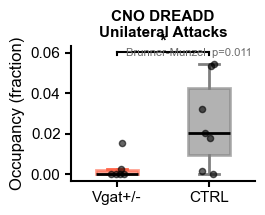

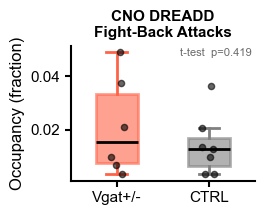

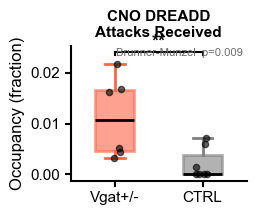


CNO DREADD — occupancy
Behavior                       Test           Stat      p_raw   Sig    Vgat+/-       CTRL
──────────────────────────────────────────────────────────────────────────────────
  unilateral_attacks           Brunner-Munzel      3.278 1.0624e-02     *     0.0031     0.0257
  fight-back_attacks           t-test        0.839 4.1947e-01           0.0213     0.0142
  attacks_received             Brunner-Munzel     -3.184 9.4210e-03    **     0.0113     0.0021


In [39]:
def plot_cno_boxplots(df, value_col, ylabel, title_prefix,
                      behaviors=COMBINED_BEHAVIORS_CNO, save_dir='./figures/'):

    # ── collect stats across behaviors for FDR correction ─────────────────────
    stats_records = []

    for beh in behaviors:
        fig, ax = plt.subplots(figsize=(2.75, 2.25))
        beh_df  = df[df['behavior'] == beh]

        groups_data = [
            beh_df[beh_df['group'] == g][value_col].dropna().values
            for g in GROUP_ORDER_CNO
        ]

        valid = [g for g in groups_data if len(g) >= 2]
        if len(valid) == 2:
            _, p_a = shapiro(groups_data[0]) if len(groups_data[0]) >= 3 \
                     else (None, 0.0)
            _, p_b = shapiro(groups_data[1]) if len(groups_data[1]) >= 3 \
                     else (None, 0.0)
            if p_a > 0.05 and p_b > 0.05:
                stat_val, p_val = ttest_ind(groups_data[0], groups_data[1])
                test_label = 't-test'
            else:
                stat_val, p_val = brunnermunzel(groups_data[0], groups_data[1],
                                                alternative='two-sided')
                test_label = 'Brunner-Munzel'
        else:
            stat_val, p_val, test_label = np.nan, np.nan, 'n/a'

        stats_records.append({
            'behavior':   beh,
            'test':       test_label,
            'stat':       stat_val,
            'p_raw':      p_val,
            'mean_vgat':  np.nanmean(groups_data[0]),
            'mean_ctrl':  np.nanmean(groups_data[1]),
        })

        # ── Boxplots (unchanged) ───────────────────────────────────────────────
        positions = [1, 2]
        box = ax.boxplot(groups_data,
                         positions=positions,
                         patch_artist=True, widths=0.45,
                         medianprops =dict(color='black', linewidth=2),
                         whiskerprops=dict(linewidth=2),
                         capprops    =dict(linewidth=2),
                         flierprops  =dict(marker='', markersize=0))

        for patch, g in zip(box['boxes'], GROUP_ORDER_CNO):
            c = GROUP_COLORS_CNO[g]
            patch.set_facecolor(c); patch.set_edgecolor(c)
            patch.set_alpha(0.6);   patch.set_linewidth(2)
        for element in ['whiskers', 'caps']:
            for item, color in zip(box[element],
                                    [GROUP_COLORS_CNO[g]
                                     for g in GROUP_ORDER_CNO
                                     for _ in (0, 1)]):
                item.set_color(color); item.set_linewidth(2)

        for j, (data, g) in enumerate(zip(groups_data, GROUP_ORDER_CNO)):
            jitter = np.random.default_rng(42+j).uniform(
                -0.08, 0.08, size=len(data))
            ax.scatter(np.full(len(data), positions[j]) + jitter,
                       data, color='black', s=20, alpha=0.6, zorder=5)

        ax.autoscale()
        y_lo, y_hi = ax.get_ylim()
        step = (y_hi - y_lo) * 0.12
        sig  = get_sig(p_val) if not np.isnan(p_val) else ''
        if sig:
            y_br = y_hi + step * 0.5
            ax.plot([1, 2], [y_br, y_br], 'k-', linewidth=1.5)
            ax.plot([1, 1], [y_br - step*0.2, y_br], 'k-', linewidth=1.5)
            ax.plot([2, 2], [y_br - step*0.2, y_br], 'k-', linewidth=1.5)
            ax.text(1.5, y_br, sig, ha='center', va='bottom',
                    fontsize=13, fontweight='bold', fontfamily='Arial')

        ax.set_xticks(positions)
        ax.set_xticklabels(GROUP_ORDER_CNO, fontsize=12, fontfamily='Arial')
        ax.set_ylabel(ylabel, fontsize=12, fontfamily='Arial')
        ax.set_title(f'{title_prefix}\n{beh.replace("_", " ").title()}',
                     fontsize=11, fontweight='bold', fontfamily='Arial')
        ax.text(0.98, 0.98, f'{test_label}  p={p_val:.3f}',
                transform=ax.transAxes, fontsize=8, fontfamily='Arial',
                ha='right', va='top', color='dimgray')
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontfamily('Arial'); tick.set_fontsize(11)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.tick_params(length=4, width=1.5)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(f'{save_dir}{value_col}_{beh}.svg', dpi=300)
        plt.show()
        plt.close()

    # FDR correction - not necessary for this analysis but here it is anyway
    valid_idx = [i for i, r in enumerate(stats_records)
                 if not np.isnan(r['p_raw'])]
    if valid_idx:
        _, p_fdr, _, _ = multipletests(
            [stats_records[i]['p_raw'] for i in valid_idx], method='fdr_bh')
        for rank, i in enumerate(valid_idx):
            stats_records[i]['p_fdr'] = p_fdr[rank]
    for r in stats_records:
        if 'p_fdr' not in r:
            r['p_fdr'] = np.nan

    print(f'\n{"="*82}')
    print(f'{title_prefix} — {value_col}')
    print(f'{"="*82}')
    print(f'{"Behavior":<30} {"Test":<8} {"Stat":>10} {"p_raw":>10} '
          f'{"Sig":>5} '
          f'{"Vgat+/-":>10} {"CTRL":>10}')
    print(f'{"─"*82}')
    for r in stats_records:
        sig      = get_sig(r['p_raw']) if not np.isnan(r['p_raw']) else 'n/a'
        stat_str = f'{r["stat"]:>10.3f}' if not np.isnan(r['stat']) else '       n/a'
        p_r_str  = f'{r["p_raw"]:>10.4e}' if not np.isnan(r['p_raw']) else '       n/a'
        print(f'  {r["behavior"]:<28} {r["test"]:<8} {stat_str} '
              f'{p_r_str} {sig:>5} '
              f'{r["mean_vgat"]:>10.4f} {r["mean_ctrl"]:>10.4f}')
    print(f'{"="*82}')

GROUP_ORDER_CNO  = ['Vgat+/-', 'CTRL']
GROUP_COLORS_CNO = {'CTRL': 'gray', 'Vgat+/-': 'tomato'}

for key, df in cno_session_dfs.items():
    for combined_name, source_cols in COMBINED_BEHAVIORS_CNO.items():
        available = [c for c in source_cols if c in df.columns]
        df[combined_name] = (df[available].sum(axis=1) > 0).astype(int)
    cno_session_dfs[key] = df

BEHAVIORS_PLOT = list(COMBINED_BEHAVIORS_CNO.keys())

# ── Recompute occupancy and latency with combined columns ─────────────────────
def compute_occupancy_cno_combined(session_dfs, behaviors=BEHAVIORS_PLOT):
    records = []
    for (animal, session, group), df in session_dfs.items():
        n_total = len(df)
        for beh in behaviors:
            if beh not in df.columns:
                continue
            n_active = df[beh].sum()
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'occupancy': n_active / n_total if n_total > 0 else np.nan,
            })
    return pd.DataFrame(records)

cno_occ_df_combined = compute_occupancy_cno_combined(cno_session_dfs)

# ── Plot ──────────────────────────────────────────────────────────────────────
print('\n── Occupancy ──')
plot_cno_boxplots(cno_occ_df_combined, value_col='occupancy',
                  ylabel='Occupancy (fraction)',
                  title_prefix='CNO DREADD',
                  behaviors=BEHAVIORS_PLOT)

In [41]:
panel_map = {'unilateral_attacks': 'left', 'fight-back_attacks': 'middle', 'attacks_received': 'right'}

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    else:
        return np.nan

stats_records = []
for beh in BEHAVIORS_PLOT:
    beh_df = cno_occ_df_combined[cno_occ_df_combined['behavior'] == beh]
    groups_data = [beh_df[beh_df['group'] == g]['occupancy'].dropna().values
                   for g in GROUP_ORDER_CNO]

    valid = [g for g in groups_data if len(g) >= 2]
    if len(valid) == 2:
        _, p_a = shapiro(groups_data[0]) if len(groups_data[0]) >= 3 else (None, 0.0)
        _, p_b = shapiro(groups_data[1]) if len(groups_data[1]) >= 3 else (None, 0.0)
        if p_a > 0.05 and p_b > 0.05:
            stat_val, p_val = ttest_ind(groups_data[0], groups_data[1])
            test_label = 't-test'
        else:
            stat_val, p_val = brunnermunzel(groups_data[0], groups_data[1], alternative='two-sided')
            test_label = 'Brunner-Munzel'
            if not np.isfinite(stat_val) or not np.isfinite(p_val):
                stat_val, p_val = mannwhitneyu(groups_data[0], groups_data[1], alternative='two-sided')
                test_label = 'Mann-Whitney U (BM degenerate — fallback)'
        df_val = compute_df_for_test(test_label, groups_data[0], groups_data[1])
    else:
        stat_val, p_val, test_label, df_val = np.nan, np.nan, 'n/a', np.nan

    stats_records.append({'behavior': beh, 'test': test_label, 'stat': stat_val,
                          'df': df_val, 'p_value': p_val})

stats_lookup = {r['behavior']: r for r in stats_records}

rows = []
for beh in BEHAVIORS_PLOT:
    beh_df = cno_occ_df_combined[cno_occ_df_combined['behavior'] == beh]
    sr = stats_lookup[beh]
    for g in GROUP_ORDER_CNO:
        vals = beh_df[beh_df['group'] == g]['occupancy'].dropna().values
        for v in vals:
            rows.append({
                'panel': panel_map[beh],
                'behavior': beh,
                'group': g,
                'occupancy': v,
                'test': sr['test'],
                'stat': sr['stat'],
                'df': sr['df'],
                'p_value': sr['p_value'],
            })

sourceData_5m = pd.DataFrame(rows)
sourceData_5m.to_csv('./sourceData/5m.csv', index=False)